# Build a Basic Chatbot with LangGraph (GRAPH API)

Components of langgraph
1. Edge
2. Nodes
3. State


Langgraph can use the following:
1. GRAPH API
2. Functional API

Start -> chatbot node -> End
 

In [4]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [5]:
class State(TypedDict):
    # Messages are of type list 
    # 'add_messages' function -> defines the way the state key is updated
    # 'add_messages' function -> appends messages to the list rather than overwriting it 
    messages: Annotated[list, add_messages]



In [6]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

In [ ]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model='groq:qwen/qwen3-32b')

In [10]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x10d155490>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10cbb1ee0>, model_name='groq:qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [29]:
llm = init_chat_model('groq:qwen/qwen3-32b')

In [30]:
# node functionality
def chatbot(state: State):
    return {'messages':[llm.invoke(state['messages'])]}

In [31]:
graph_builder = StateGraph(State)

# node
graph_builder.add_node('llmchatbot', chatbot)

# edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# compile graph
graph = graph_builder.compile()

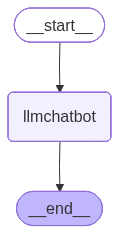

In [32]:
# visualise graph 
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)
    pass

In [33]:
response = graph.invoke({'messages': "Hi"})

In [34]:
response['messages']

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='4244823c-9f72-4979-af2a-d0ba8b7a7a2b'),
 AIMessage(content='<think>\nOkay, the user said "Hi". I should respond in a friendly and welcoming way. Let me make sure to keep it open-ended so they feel comfortable to ask anything. Maybe add an emoji to keep it approachable. Let me check for any typos. Alright, that should work.\n</think>\n\nHi! How can I help you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 9, 'total_tokens': 84, 'completion_time': 0.17277205, 'completion_tokens_details': None, 'prompt_time': 0.000359794, 'prompt_tokens_details': None, 'queue_time': 0.048881923, 'total_time': 0.173131844}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2427-7d4f-7841-a021-6dbf541dcbf1-0', tool_calls=[], invalid_tool

In [ ]:
response['messages'][-1]

In [ ]:
response['messages'][-1].content

In [ ]:
for event in graph.stream({'messages':'hi, how are you'}):
    print(event)


In [ ]:
for event in graph.stream({'messages':'hi, how are you'}):
    for value in event.values():
        print(value['messages'][-1].content)


# Chatbot with Tools

In [14]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("MLE entry level jobs with salary above 14 lakhs")

{'query': 'MLE entry level jobs with salary above 14 lakhs',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.linkedin.com/jobs/entry-level-machine-learning-engineer-jobs',
   'title': '1,000+ Entry Level Machine Learning Engineer jobs in United States',
   'content': "Today's top 1000+ Entry Level Machine Learning Engineer jobs in United States. Leverage your professional network, and get hired. New Entry Level Machine",
   'score': 0.29550478,
   'raw_content': None},
  {'url': 'https://www.instagram.com/reel/DU4tNc2gHZD',
   'title': 'Top AI Companies Hiring From One Challenge (₹20 Lakh Rewards ...',
   'content': '[AI careers, data analyst salary, ML engineer salary, AI research ... Claude Corps Fellowship, Anthropic Jobs, Entry Level AI Jobs, AI',
   'score': 0.20895302,
   'raw_content': None}],
 'response_time': 0.0,
 'request_id': 'b7c3bcbd-fbf5-421d-a754-729d9557d7ba'}

In [23]:
# custom function 
def multiply(a: int, b: int) -> int:
    """Multiple a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b


In [24]:
tools = [tool, multiply]

llm_with_tool = llm.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x10d7f69f0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10edfd130>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, ac

In [ ]:
# state graph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# node definition
def tool_calling_llm(state:State):
    return {'messages':[llm_with_tool.invoke(state['messages'])]}

# graph
builder = StateGraph(State)
builder.add_node('tool_calling_llm', tool_calling_llm)
builder.add_node('tools', ToolNode(tools))

# edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    'tool_calling_llm',
    # if latest message (result) from assistance is a tool call -> tool_condition routes ot tools
    # if latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge('tools', END)

# compile the graph 
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
response = graph.invoke({'messages': "what is the recent stock news"})
response

In [ ]:
response['messages'][-1].content

In [ ]:
for m in response['messages']:
    m.pretty_print()


In [ ]:
response = graph.invoke({'messages': "what is 34 multiply by 97"})
response

In [ ]:
for m in response['messages']:
    m.pretty_print()

# ReAct Agent
rather then ending after the ToolNode, after ToolNode go back to LLM 

1. Act
2. Observe
3. Reason 

In [ ]:
# state graph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# node definition
def tool_calling_llm(state:State):
    return {'messages':[llm_with_tool.invoke(state['messages'])]}

# graph
builder = StateGraph(State)
builder.add_node('tool_calling_llm', tool_calling_llm)
builder.add_node('tools', ToolNode(tools))

# edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    'tool_calling_llm',
    # if latest message (result) from assistance is a tool call -> tool_condition routes ot tools
    # if latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge('tools', 'tool_calling_llm')

# compile the graph 
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
response = graph.invoke({'messages': 'Give me the recent mle jobs and then multiply 328 by 78'})
for m in response['messages']:
    m.pretty_print()

# Adding Memory in Agentic Graph

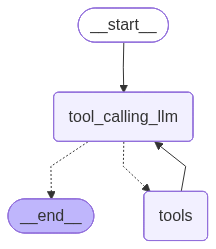

In [35]:
# stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition 
from langgraph.checkpoint.memory import MemorySaver 

memory = MemorySaver()

# Node 
def tool_calling_llm(state: State):
    return {'messages':[llm_with_tool.invoke(state['messages'])]}


# graph
builder = StateGraph(State)
builder.add_node('tool_calling_llm', tool_calling_llm)
builder.add_node('tools', ToolNode(tools))

# edges
builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    tools_condition
)
builder.add_edge('tools', 'tool_calling_llm')

# compile the graph 
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
config = {'configurable':{'thread_id': '123'}}

response = graph.invoke({'messages': 'Hi i am john doe'}, config=config)
response

{'messages': [HumanMessage(content='Hi i am john doe', additional_kwargs={}, response_metadata={}, id='94c6f6c1-b73c-4e6a-b899-7c0d53b32dd8'),
  AIMessage(content='Hello, John Doe! How can I assist you today? If you have any questions or need information, feel free to ask!', additional_kwargs={'reasoning_content': "Okay, the user introduced himself as John Doe. I need to respond appropriately. Since there's no specific query here that requires using the provided tools, my best bet is to just acknowledge his introduction and offer assistance. Let me check if there's any function I need to call. The tools given are for searching and multiplying, which don't apply here. So, no function call needed. I'll keep it friendly and ask how I can help him.\n"}, response_metadata={'token_usage': {'completion_tokens': 122, 'prompt_tokens': 1786, 'total_tokens': 1908, 'completion_time': 0.223305361, 'completion_tokens_details': {'reasoning_tokens': 91}, 'prompt_time': 0.11797915, 'prompt_tokens_detai

In [37]:
response['messages'][-1].content

'Hello, John Doe! How can I assist you today? If you have any questions or need information, feel free to ask!'

In [28]:
response = graph.invoke({'messages': 'Give me the recent mle jobs and then multiply 328 by 78'}, config=config)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi i am john doe
================================ Human Message =================================

Give me the recent mle jobs and then multiply 328 by 78


In [38]:
response = graph.invoke({'messages': 'what is my name'}, config=config)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi i am john doe
================================== Ai Message ==================================

Hello, John Doe! How can I assist you today? If you have any questions or need information, feel free to ask!
================================ Human Message =================================

what is my name
================================== Ai Message ==================================

Your name is John Doe. Let me know if there's anything else I can help with!


# Streaming

Methods: .stream() and .astream()

They are sync and async methods respectively

Additional parameters in streaming modes:
- values: streams full state after each node is called
- updates: streams updates to the state after each node is called

In [40]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [46]:
def superbot(state: State):
    return {'messages': [llm_with_tool.invoke(state['messages'])]}


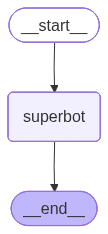

In [47]:
# graph
graph = StateGraph(State)

# node
graph.add_node('superbot', superbot)

# edges
graph.add_edge(START,'superbot')
graph.add_edge('superbot', END)

# compile 
graph_builder = graph.compile(checkpointer=memory)

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [48]:
config = {'configurable':{'thread_id': '123'}}

response = graph_builder.invoke({'messages': 'Hi i am john doe and I like chess'}, config=config)
response

{'messages': [HumanMessage(content='Hi i am john doe and I like chess', additional_kwargs={}, response_metadata={}, id='4ca2d739-c972-43b3-a951-c7459457fda3'),
  HumanMessage(content='Hi i am john doe and I like chess', additional_kwargs={}, response_metadata={}, id='63d73e89-b4a9-4a86-bbc5-6b4b9673ef14'),
  AIMessage(content='Nice to meet you, John! 🎉 Chess is a fantastic game—how long have you been playing? Do you have a favorite opening or strategy?', additional_kwargs={'reasoning_content': 'Okay, the user introduced himself as John Doe and mentioned he likes chess. Let me think about how to respond appropriately.\n\nFirst, I should acknowledge his introduction. A simple "Nice to meet you" seems friendly. Then, since he mentioned chess, I can express interest in that. Maybe ask how long he\'s been playing or if he has a favorite opening. That shows I\'m engaged and want to continue the conversation.\n\nWait, but the user might be looking for different responses. Let me check if ther

In [49]:
config = {'configurable': {'thread_id': '56'}}

for chunk in graph_builder.stream({'messages':'Hi, my name is john and I like soccer'}, config, stream_mode='updates'):
    print(chunk)

{'superbot': {'messages': [AIMessage(content="Hello John! It's great to meet you. Since you mentioned you like soccer, do you follow any particular teams or enjoy playing it? Feel free to ask if you have any questions or need help with something related to soccer or anything else!", additional_kwargs={'reasoning_content': "Okay, the user introduced himself as John and mentioned he likes soccer. I need to respond appropriately. Since there's no specific question here, my job is to acknowledge his introduction and maybe ask a follow-up question to keep the conversation going.\n\nFirst, I should greet him back and express that I'm here to help. Then, perhaps ask about his interests related to soccer. Maybe he wants to know about recent matches, teams, or something else. But I don't see any functions related to soccer information. The available tools are tavily_search and multiply. Since he likes soccer, maybe he might ask for search-related help, but he hasn't asked for anything yet.\n\nW

In [50]:
for chunk in graph_builder.stream({'messages':'Hi, my name is john and I like soccer'}, config, stream_mode='values'):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is john and I like soccer', additional_kwargs={}, response_metadata={}, id='dccae3b7-d986-4b13-a685-bbe2625f2c1a'), AIMessage(content="Hello John! It's great to meet you. Since you mentioned you like soccer, do you follow any particular teams or enjoy playing it? Feel free to ask if you have any questions or need help with something related to soccer or anything else!", additional_kwargs={'reasoning_content': "Okay, the user introduced himself as John and mentioned he likes soccer. I need to respond appropriately. Since there's no specific question here, my job is to acknowledge his introduction and maybe ask a follow-up question to keep the conversation going.\n\nFirst, I should greet him back and express that I'm here to help. Then, perhaps ask about his interests related to soccer. Maybe he wants to know about recent matches, teams, or something else. But I don't see any functions related to soccer information. The available tools are 

In [51]:
config = {'configurable': {'thread_id':'78'}}

async for event in graph_builder.astream_events({'messages':['Hi, i like jogging']}, config, version='v2'):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi, i like jogging']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f2439-a691-7bf1-b6c3-4567b10d7b56', 'metadata': {'thread_id': '78', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, i like jogging', additional_kwargs={}, response_metadata={}, id='4fd3a6f4-5db4-4173-870e-c2271ec021c7')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '019f2439-a694-7090-95da-640cd21902e7', 'metadata': {'thread_id': '78', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:b7305766-03f2-bee8-ac4c-1cce812748a9'}, 'parent_ids': ['019f2439-a691-7bf1-b6c3-4567b10d7b56']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Hi, i like jogging', addition